# Capítulo 6: Análisis de Comportamiento de Usuarios (UBA)

**Guía Técnica:** Inteligencia Artificial en Ciberseguridad  
**Mayo 2026**

---

## 6.1. Introducción

El **UBA** (*User Behavior Analytics*) detecta amenazas internas y cuentas comprometidas analizando
desviaciones estadísticas respecto al comportamiento habitual de cada usuario.  
Complementa la detección de red (Cap. 03) y el triaje de incidentes (Cap. 05): cuando el SVM
clasifica un incidente como **Alto** o **Crítico**, UBA agrega contexto sobre si el usuario
involucrado se comportó de forma anómala.

### Cadena de dependencias

```
Cap. 05 → svm_severity.pkl  ──► (referencia conceptual)
Cap. 06 → user_profiles.pkl ──► Cap. 10  (Pipeline completo)
```

### Contenido
| Sección | Técnica |
|---|---|
| 6.0 | Generación de `user_activity_logs.csv` |
| 6.1 | Construcción de perfiles de usuario |
| 6.2 | Detección de anomalías con Z-score |
| 6.3 | Visualización y alertas |

---
## Sección 0: Generación de `user_activity_logs.csv`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(seed=42)

USUARIOS = [f"user_{i:02d}" for i in range(1, 16)]  # 15 usuarios
N_DIAS   = 60   # 60 días de histórico
N_ACCESOS_DIA = 5  # promedio de accesos por usuario por día

registros = []
for uid in USUARIOS:
    # Perfil "normal" del usuario (varía por usuario)
    hora_media   = RNG.uniform(7, 18)        # hora habitual de inicio de sesión
    hora_std     = RNG.uniform(0.5, 2.0)
    bytes_media  = RNG.uniform(50_000, 500_000)
    bytes_std    = bytes_media * 0.3
    ip_base      = f"192.168.{RNG.integers(1,10)}.{RNG.integers(1,50)}"

    n_total = N_DIAS * RNG.integers(3, 8)    # total de accesos en el período
    for _ in range(int(n_total)):
        hora_login      = float(np.clip(RNG.normal(hora_media, hora_std), 0, 23))
        bytes_sent      = float(np.clip(RNG.normal(bytes_media, bytes_std), 0, None))
        failed_logins   = int(RNG.choice([0, 1, 2], p=[0.85, 0.12, 0.03]))
        num_accesos_dia = int(RNG.integers(1, 10))
        # IP: 95 % desde IP base, 5 % desde externa
        ip = ip_base if RNG.random() < 0.95 else f"{RNG.integers(1,255)}.{RNG.integers(1,255)}.{RNG.integers(1,255)}.1"

        registros.append({
            "user_id"        : uid,
            "hora_login"     : round(hora_login, 2),
            "ip_origen"      : ip,
            "bytes_sent"     : round(bytes_sent, 2),
            "failed_logins"  : failed_logins,
            "num_accesos_dia": num_accesos_dia,
        })

logs = pd.DataFrame(registros)
logs.to_csv(DATA_DIR / "user_activity_logs.csv", index=False)

print(f"user_activity_logs.csv  →  {len(logs):,} registros, {logs['user_id'].nunique()} usuarios")
print(logs.groupby("user_id").size().rename("registros").to_string())

user_activity_logs.csv  →  4,380 registros, 15 usuarios
user_id
user_01    240
user_02    180
user_03    300
user_04    240
user_05    180
user_06    420
user_07    180
user_08    180
user_09    300
user_10    180
user_11    360
user_12    420
user_13    420
user_14    360
user_15    420


---
## Sección 6.1: Construcción de perfiles de usuario

Para cada usuario calculamos media y desviación estándar de las métricas de comportamiento
(**hora_login**, **bytes_sent**, **failed_logins**, **num_accesos_dia**).  
Este perfil representa la *línea base* de actividad normal.

In [2]:
METRICAS = ["hora_login", "bytes_sent", "failed_logins", "num_accesos_dia"]

def construir_perfil_usuario(logs: pd.DataFrame, usuario: str) -> dict:
    """Devuelve {metrica: {mean, std}} para un usuario."""
    subset = logs[logs["user_id"] == usuario][METRICAS]
    perfil = {}
    for col in METRICAS:
        perfil[col] = {
            "mean": subset[col].mean(),
            "std" : max(subset[col].std(), 1e-6),  # evitar div/0
        }
    return perfil

logs = pd.read_csv(DATA_DIR / "user_activity_logs.csv")
perfiles = {uid: construir_perfil_usuario(logs, uid) for uid in USUARIOS}

# Mostrar perfil de un usuario de ejemplo
uid_ejemplo = "user_01"
print(f"Perfil de {uid_ejemplo}:")
for metrica, stats in perfiles[uid_ejemplo].items():
    print(f"  {metrica:<22} mean={stats['mean']:>10.2f}  std={stats['std']:>10.2f}")

Perfil de user_01:
  hora_login             mean=     15.42  std=      1.09
  bytes_sent             mean= 425932.87  std= 127414.01
  failed_logins          mean=      0.17  std=      0.45
  num_accesos_dia        mean=      5.40  std=      2.53


---
## Sección 6.2: Detección de anomalías con Z-score

Para un nuevo evento de usuario, calculamos el **Z-score** de cada métrica:

$$z = \frac{x - \mu}{\sigma}$$

Si $|z| > \text{umbral}$ (por defecto 3.0) en alguna métrica, se genera una alerta.

In [3]:
def detectar_comportamiento_anomalo(
    evento : dict,
    perfil : dict,
    umbral_z: float = 3.0
) -> list[dict]:
    """
    Compara un evento contra el perfil del usuario.
    Devuelve lista de alertas: [{metrica, valor, z_score}]
    """
    alertas = []
    for metrica, stats in perfil.items():
        if metrica not in evento:
            continue
        z = (evento[metrica] - stats["mean"]) / stats["std"]
        if abs(z) > umbral_z:
            alertas.append({
                "metrica": metrica,
                "valor"  : evento[metrica],
                "z_score": round(z, 3),
            })
    return alertas

print("Motor de detección UBA definido.")

Motor de detección UBA definido.


In [4]:
# ── Eventos de prueba ──────────────────────────────────────────────────────────
eventos_prueba = [
    # Evento normal → esperamos 0 alertas
    {
        "user_id"        : "user_01",
        "hora_login"     : perfiles["user_01"]["hora_login"]["mean"],
        "bytes_sent"     : perfiles["user_01"]["bytes_sent"]["mean"],
        "failed_logins"  : 0,
        "num_accesos_dia": 5,
    },
    # Acceso a las 3 AM con descarga masiva → sospechoso
    {
        "user_id"        : "user_01",
        "hora_login"     : 3.0,
        "bytes_sent"     : 8_000_000,
        "failed_logins"  : 5,
        "num_accesos_dia": 1,
    },
    # Múltiples fallos de login en horario normal → posible fuerza bruta
    {
        "user_id"        : "user_05",
        "hora_login"     : perfiles["user_05"]["hora_login"]["mean"],
        "bytes_sent"     : perfiles["user_05"]["bytes_sent"]["mean"],
        "failed_logins"  : 20,
        "num_accesos_dia": 3,
    },
]

for ev in eventos_prueba:
    uid     = ev["user_id"]
    alertas = detectar_comportamiento_anomalo(ev, perfiles[uid])
    estado  = "NORMAL" if not alertas else "⚠ ANOMALÍA"
    print(f"\n{uid} → {estado}")
    for a in alertas:
        print(f"  [{a['metrica']}] valor={a['valor']:.2f}  Z={a['z_score']}")


user_01 → NORMAL

user_01 → ⚠ ANOMALÍA
  [hora_login] valor=3.00  Z=-11.385
  [bytes_sent] valor=8000000.00  Z=59.445
  [failed_logins] valor=5.00  Z=10.776

user_05 → ⚠ ANOMALÍA
  [failed_logins] valor=20.00  Z=41.431


---
## Sección 6.3: Visualización y análisis de desviaciones

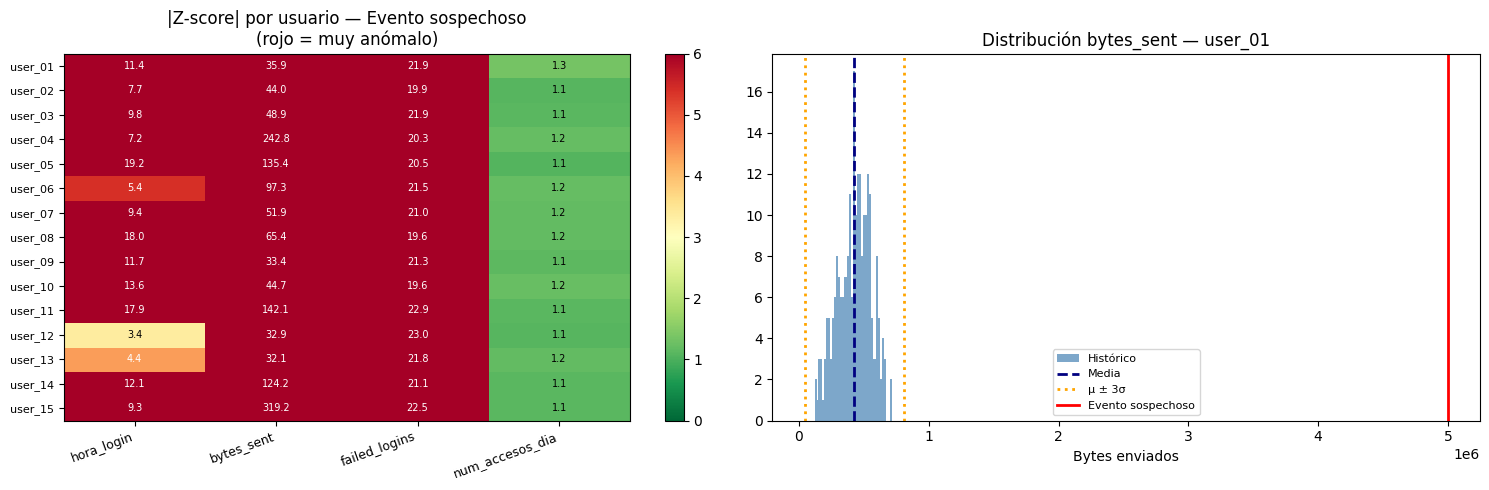

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Panel de Z-scores para todos los usuarios en un evento fijo ────────────────
# Evento sospechoso genérico: hora=3, bytes=5 M, failed=10
evento_sospechoso = {
    "hora_login"     : 3.0,
    "bytes_sent"     : 5_000_000,
    "failed_logins"  : 10,
    "num_accesos_dia": 2,
}

z_matrix = []
for uid in USUARIOS:
    row = []
    for m in METRICAS:
        z = (evento_sospechoso[m] - perfiles[uid][m]["mean"]) / perfiles[uid][m]["std"]
        row.append(abs(z))
    z_matrix.append(row)

z_df = pd.DataFrame(z_matrix, index=USUARIOS, columns=METRICAS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de Z-scores
im = axes[0].imshow(z_df.values, cmap="RdYlGn_r", vmin=0, vmax=6, aspect="auto")
axes[0].set_xticks(range(len(METRICAS)))
axes[0].set_xticklabels(METRICAS, rotation=20, ha="right", fontsize=9)
axes[0].set_yticks(range(len(USUARIOS)))
axes[0].set_yticklabels(USUARIOS, fontsize=8)
axes[0].set_title("|Z-score| por usuario — Evento sospechoso\n(rojo = muy anómalo)")
plt.colorbar(im, ax=axes[0])
for i in range(len(USUARIOS)):
    for j in range(len(METRICAS)):
        axes[0].text(j, i, f"{z_df.values[i,j]:.1f}",
                     ha="center", va="center", fontsize=7,
                     color="white" if z_df.values[i,j] > 3.5 else "black")

# Distribución de bytes_sent de user_01 con umbral de evento sospechoso
uid_plot = "user_01"
datos_u  = logs[logs.user_id == uid_plot]["bytes_sent"]
media    = perfiles[uid_plot]["bytes_sent"]["mean"]
std_val  = perfiles[uid_plot]["bytes_sent"]["std"]

axes[1].hist(datos_u, bins=40, color="steelblue", alpha=0.7, label="Histórico")
axes[1].axvline(media,               color="navy",   lw=2, linestyle="--", label="Media")
axes[1].axvline(media + 3 * std_val, color="orange", lw=2, linestyle=":",  label="μ ± 3σ")
axes[1].axvline(media - 3 * std_val, color="orange", lw=2, linestyle=":")
axes[1].axvline(evento_sospechoso["bytes_sent"], color="red", lw=2, label="Evento sospechoso")
axes[1].set_xlabel("Bytes enviados")
axes[1].set_title(f"Distribución bytes_sent — {uid_plot}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "uba_resultados.png", dpi=150)
plt.show()

---
## Persistencia de perfiles → Capítulo 10

Guardamos el diccionario de perfiles para cargarlo en el Pipeline completo del Capítulo 10.

In [6]:
import joblib

joblib.dump(perfiles, MODELS_DIR / "user_profiles.pkl")

print("Modelos guardados en ../models/")
print("  user_profiles.pkl  → cargado en Cap. 10")

Modelos guardados en ../models/
  user_profiles.pkl  → cargado en Cap. 10


---
**Siguiente:** Capítulo 7 → Explicabilidad de Modelos de IA (XAI / SHAP)